<a href="https://colab.research.google.com/github/KartikMantri/U-Kan-repo/blob/main/wnet%2Brecon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import time
import numpy as np
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

print(f"CUDA available: {torch.cuda.is_available()}")

CUDA available: True


In [4]:
# Upload your kaggle.json (Kaggle account -> Settings -> API -> Create New Token)
from google.colab import files
print("Upload your kaggle.json now:")
uploaded = files.upload()  # select kaggle.json in the file picker

import os
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

!pip install -q kaggle

Upload your kaggle.json now:


Saving kaggle.json to kaggle.json


In [6]:
# Dataset: https://www.kaggle.com/datasets/arnavjain1/glaucoma-datasets
# (contains ORIGA, REFUGE, and G1020 fundus images + OD/OC masks)
!kaggle datasets download -d arnavjain1/glaucoma-datasets -p /content/kaggle_data --unzip

# Inspect what actually got downloaded before wiring up paths below
import os
for root, dirs, filenames in os.walk("/content/kaggle_data"):
    depth = root.replace("/content/kaggle_data", "").count(os.sep)
    if depth <= 2:  # keep it readable, don't dump every file
        print("  " * depth + os.path.basename(root) + "/")
        for f in filenames[:5]:
            print("  " * (depth + 1) + f)
        if len(filenames) > 5:
            print("  " * (depth + 1) + f"... ({len(filenames)} files total)")

Dataset URL: https://www.kaggle.com/datasets/arnavjain1/glaucoma-datasets
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.55G/5.55G [00:54<00:00, 110MB/s] 

kaggle_data/
  models/
    refuge_clf.pkl
    refuge_segmentation.pth
  ORIGA/
    OrigaList.csv
    origa_info.csv
    Images/
      411.jpg
      178.jpg
      105.jpg
      261.jpg
      299.jpg
      ... (650 files total)
    Semi-automatic-annotations/
      381.mat
      274.mat
      265.mat
      591.mat
      602.mat
      ... (652 files total)
    Images_Square/
      411.jpg
      178.jpg
      105.jpg
      261.jpg
      299.jpg
      ... (651 files total)
    Masks_Square/
      061.png
      005.png
      517.png
      306.png
      071.png
      ... (651 files total)
    Masks_Cropped/
      061.png
      005.png
      517.png
      306.png
      071.png
      ... (650 files total)
    Images_Cropped/
      411.jpg
      178.jpg
      105.jpg
      261.jpg
      299.jpg
      ... (650 fi

In [7]:
import json, numpy as np
from PIL import Image

REFUGE_ROOT = "/content/kaggle_data/REFUGE"

# 1. What's inside the split index.json files?
for split in ["train", "val", "test"]:
    path = f"{REFUGE_ROOT}/{split}/index.json"
    with open(path) as f:
        data = json.load(f)
    print(f"--- {split}/index.json ---")
    print(f"type: {type(data)}")
    if isinstance(data, dict):
        print(f"keys (first 5): {list(data.keys())[:5]}")
        first_key = list(data.keys())[0]
        print(f"sample entry: {first_key} -> {data[first_key]}")
    elif isinstance(data, list):
        print(f"length: {len(data)}")
        print(f"sample entries: {data[:5]}")
    print()

# 2. What raw pixel values actually show up in the masks?
import os
mask_dir = f"{REFUGE_ROOT}/Masks_Square"
sample_masks = sorted(os.listdir(mask_dir))[:5]
for fname in sample_masks:
    m = np.array(Image.open(os.path.join(mask_dir, fname)))
    print(f"{fname}: shape={m.shape}, dtype={m.dtype}, unique values={np.unique(m)}")

--- train/index.json ---
type: <class 'dict'>
keys (first 5): ['0', '1', '2', '3', '4']
sample entry: 0 -> {'ImgName': 'g0001.jpg', 'Fovea_X': 1057.95, 'Fovea_Y': 1076.52, 'Size_X': 2124, 'Size_Y': 2056, 'Label': 1}

--- val/index.json ---
type: <class 'dict'>
keys (first 5): ['0', '1', '2', '3', '4']
sample entry: 0 -> {'ImgName': 'V0001.jpg', 'Label': 0, 'Fovea_X': 1050.07, 'Fovea_Y': 858.55, 'Size_X': 1634, 'Size_Y': 1634}

--- test/index.json ---
type: <class 'dict'>
keys (first 5): ['0', '1', '2', '3', '4']
sample entry: 0 -> {'ImgName': 'T0001.jpg', 'Size_X': 1634, 'Size_Y': 1634}

T0001.png: shape=(1634, 1634), dtype=uint8, unique values=[0 1 2]
T0002.png: shape=(1634, 1634), dtype=uint8, unique values=[0 1 2]
T0003.png: shape=(1634, 1634), dtype=uint8, unique values=[0 1 2]
T0004.png: shape=(1634, 1634), dtype=uint8, unique values=[0 1 2]
T0005.png: shape=(1634, 1634), dtype=uint8, unique values=[0 1 2]


In [8]:
import json, numpy as np
from PIL import Image
import os

REFUGE_ROOT = "/content/kaggle_data/REFUGE"

# 1. Infer which integer = which class by pixel count proportions
mask_dir = f"{REFUGE_ROOT}/Masks_Square"
sample_masks = sorted(os.listdir(mask_dir))[:20]
totals = {0: 0, 1: 0, 2: 0}
for fname in sample_masks:
    m = np.array(Image.open(os.path.join(mask_dir, fname)))
    vals, counts = np.unique(m, return_counts=True)
    for v, c in zip(vals, counts):
        totals[int(v)] += int(c)

print("Pixel totals across 20 sample masks (label -> total pixel count):")
for label, count in sorted(totals.items(), key=lambda x: -x[1]):
    print(f"  {label}: {count:,}")
print("\nExpect: largest count = background, middle = disc, smallest = cup")

# 2. Inspect the split index.json files
for split in ["train", "val", "test"]:
    path = f"{REFUGE_ROOT}/{split}/index.json"
    with open(path) as f:
        data = json.load(f)
    print(f"\n--- {split}/index.json ---")
    print(f"type: {type(data)}")
    if isinstance(data, dict):
        keys = list(data.keys())
        print(f"count: {len(keys)}, sample keys: {keys[:3]}")
        print(f"sample entry: {keys[0]} -> {data[keys[0]]}")
    elif isinstance(data, list):
        print(f"count: {len(data)}, sample entries: {data[:3]}")

Pixel totals across 20 sample masks (label -> total pixel count):
  0: 52,563,734
  1: 605,010
  2: 230,376

Expect: largest count = background, middle = disc, smallest = cup

--- train/index.json ---
type: <class 'dict'>
count: 400, sample keys: ['0', '1', '2']
sample entry: 0 -> {'ImgName': 'g0001.jpg', 'Fovea_X': 1057.95, 'Fovea_Y': 1076.52, 'Size_X': 2124, 'Size_Y': 2056, 'Label': 1}

--- val/index.json ---
type: <class 'dict'>
count: 400, sample keys: ['0', '1', '2']
sample entry: 0 -> {'ImgName': 'V0001.jpg', 'Label': 0, 'Fovea_X': 1050.07, 'Fovea_Y': 858.55, 'Size_X': 1634, 'Size_Y': 1634}

--- test/index.json ---
type: <class 'dict'>
count: 400, sample keys: ['0', '1', '2']
sample entry: 0 -> {'ImgName': 'T0001.jpg', 'Size_X': 1634, 'Size_Y': 1634}


In [9]:
import os

print("Does /content/kaggle_data exist?", os.path.exists("/content/kaggle_data"))
print("Does /content/kaggle_data/REFUGE exist?", os.path.exists("/content/kaggle_data/REFUGE"))
if os.path.exists("/content/kaggle_data/REFUGE"):
    print("Contents of REFUGE/:", os.listdir("/content/kaggle_data/REFUGE"))

print("\nDoes /content/data exist?", os.path.exists("/content/data"))
if os.path.exists("/content/data"):
    for root, dirs, fnames in os.walk("/content/data"):
        print(root, "->", len(fnames), "files")

Does /content/kaggle_data exist? True
Does /content/kaggle_data/REFUGE exist? True
Contents of REFUGE/: ['test', 'Images_Square', 'val', 'Masks_Square', 'train']

Does /content/data exist? False


In [10]:
REFUGE_ROOT = "/content/kaggle_data/REFUGE"
OUT_ROOT = "/content/data"

def organize_split(split_name):
    with open(f"{REFUGE_ROOT}/{split_name}/index.json") as f:
        index = json.load(f)

    img_out = f"{OUT_ROOT}/{split_name}/images"
    mask_out = f"{OUT_ROOT}/{split_name}/masks"
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(mask_out, exist_ok=True)

    n_ok, n_missing = 0, 0
    for entry in index.values():
        stem = os.path.splitext(entry["ImgName"])[0]
        src_img = f"{REFUGE_ROOT}/Images_Square/{stem}.jpg"
        src_mask = f"{REFUGE_ROOT}/Masks_Square/{stem}.png"

        if not (os.path.exists(src_img) and os.path.exists(src_mask)):
            n_missing += 1
            continue

        dst_img = f"{img_out}/{stem}.jpg"
        dst_mask = f"{mask_out}/{stem}.png"
        if not os.path.exists(dst_img):
            os.symlink(src_img, dst_img)
        if not os.path.exists(dst_mask):
            os.symlink(src_mask, dst_mask)
        n_ok += 1

    print(f"{split_name}: {n_ok} pairs linked, {n_missing} missing")

for split in ["train", "val", "test"]:
    organize_split(split)

train: 400 pairs linked, 0 missing
val: 400 pairs linked, 0 missing
test: 400 pairs linked, 0 missing


In [11]:
IMG_SIZE = 256
NUM_CLASSES = 3  # 0=background, 1=disc, 2=cup

CONFIG = dict(
    train_image_dir="/content/data/train/images",
    train_mask_dir="/content/data/train/masks",
    val_image_dir="/content/data/val/images",
    val_mask_dir="/content/data/val/masks",
    # confirmed via pixel-count check: masks are already {0=bg,1=disc,2=cup},
    # so no raw-value remapping is needed for this Kaggle repackaging.
    mask_format="already_012",
    batch_size=8,
    epochs=100,
    lr=1e-3,
    weight_decay=1e-5,
    num_workers=2,
    checkpoint_path="/content/best_unet.pth",
    device="cuda" if torch.cuda.is_available() else "cpu",
)

In [12]:
import cv2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class FundusSegDataset(Dataset):
    """
    image_dir/  -> RGB fundus images (.jpg)
    mask_dir/   -> single-channel masks (.png), same filename stem,
                   pixel values already {0,1,2} = {bg, disc, cup}.

    Augmentation now includes rotation and brightness/contrast jitter on
    top of flips - specifically targeting the train/val domain gap we
    saw (REFUGE train and val/test images come from different cameras
    with different color/illumination characteristics). Forcing the
    model to be robust to rotation and photometric variation during
    training should help it generalize across that gap instead of
    overfitting to train-camera specifics.
    """
    def __init__(self, image_dir, mask_dir, filenames, mask_format="already_012",
                 img_size=IMG_SIZE, augment=False):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.filenames = filenames
        self.mask_format = mask_format
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.filenames)

    def _load_mask(self, mask_path):
        mask = Image.open(mask_path)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        mask = np.array(mask)
        if mask.ndim == 3:
            mask = mask[..., 0]
        return mask.astype(np.uint8)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img_path = os.path.join(self.image_dir, fname)
        stem = os.path.splitext(fname)[0]

        mask_path = None
        for ext in [".png", ".bmp", ".jpg", ".jpeg", ".tif"]:
            cand = os.path.join(self.mask_dir, stem + ext)
            if os.path.exists(cand):
                mask_path = cand
                break
        if mask_path is None:
            raise FileNotFoundError(f"No mask found for {fname} in {self.mask_dir}")

        image = Image.open(img_path).convert("RGB")
        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)
        image = np.array(image).astype(np.float32) / 255.0

        mask = self._load_mask(mask_path)

        if self.augment:
            image, mask = self._augment(image, mask)

        mean = np.array(IMAGENET_MEAN, dtype=np.float32)
        std = np.array(IMAGENET_STD, dtype=np.float32)
        image = (image - mean) / std

        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).long()
        return image, mask

    def _augment(self, image, mask):
        # flips
        if np.random.rand() < 0.5:
            image = np.ascontiguousarray(image[:, ::-1, :])
            mask = np.ascontiguousarray(mask[:, ::-1])
        if np.random.rand() < 0.5:
            image = np.ascontiguousarray(image[::-1, :, :])
            mask = np.ascontiguousarray(mask[::-1, :])

        # rotation - image and mask must use the SAME transform matrix,
        # but different interpolation (mask needs NEAREST to keep valid
        # class labels, image can use smooth LINEAR)
        if np.random.rand() < 0.5:
            angle = np.random.uniform(-15, 15)
            h, w = image.shape[:2]
            center = (w / 2, h / 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            image = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR,
                                    borderMode=cv2.BORDER_CONSTANT, borderValue=0)
            mask = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST,
                                   borderMode=cv2.BORDER_CONSTANT, borderValue=0)

        # brightness/contrast jitter - image only, mask untouched.
        # Targets exactly the kind of camera-to-camera photometric
        # difference behind the train/val domain gap.
        if np.random.rand() < 0.5:
            contrast = np.random.uniform(0.8, 1.2)
            brightness = np.random.uniform(-0.15, 0.15)
            image = image * contrast + brightness
            image = np.clip(image, 0.0, 1.0)

        return image, mask

In [14]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:00


In [13]:
# cell 7
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool_conv = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))

    def forward(self, x):
        return self.pool_conv(x)


class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        diff_y = skip.size(2) - x.size(2)
        diff_x = skip.size(3) - x.size(3)
        x = nn.functional.pad(x, [diff_x // 2, diff_x - diff_x // 2,
                                   diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=NUM_CLASSES, base=32):
        super().__init__()
        self.inc = DoubleConv(in_channels, base)
        self.down1 = Down(base, base * 2)
        self.down2 = Down(base * 2, base * 4)
        self.down3 = Down(base * 4, base * 8)
        self.down4 = Down(base * 8, base * 16)

        self.up1 = Up(base * 16, base * 8)
        self.up2 = Up(base * 8, base * 4)
        self.up3 = Up(base * 4, base * 2)
        self.up4 = Up(base * 2, base)

        self.outc = nn.Conv2d(base, num_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)  # raw logits, no softmax
        return logits

In [15]:
# cell 8
class ConfusionMatrixMeter:
    """
    Accumulates one confusion matrix over an entire epoch/split, then
    computes precision/recall/F1/dice/IoU ONCE from the totals. This is
    the correct way to do it - averaging per-batch metrics is wrong when
    class pixel counts vary a lot between batches (cup pixels are a tiny
    fraction of each image).
    """
    def __init__(self, num_classes: int):
        self.num_classes = num_classes
        self.reset()

    def reset(self):
        self.cm = np.zeros((self.num_classes, self.num_classes), dtype=np.int64)

    @torch.no_grad()
    def update(self, preds: torch.Tensor, targets: torch.Tensor):
        preds = preds.detach().cpu().numpy().reshape(-1)
        targets = targets.detach().cpu().numpy().reshape(-1)
        n = self.num_classes
        idx = n * targets.astype(np.int64) + preds.astype(np.int64)
        cm = np.bincount(idx, minlength=n * n).reshape(n, n)
        self.cm += cm

    def compute(self):
        # rows = ground truth, cols = predicted
        cm = self.cm.astype(np.float64)
        n = self.num_classes
        eps = 1e-7

        precision = np.zeros(n)
        recall = np.zeros(n)
        f1 = np.zeros(n)
        dice = np.zeros(n)
        iou = np.zeros(n)

        for c in range(n):
            tp = cm[c, c]
            fp = cm[:, c].sum() - tp
            fn = cm[c, :].sum() - tp

            precision[c] = tp / (tp + fp + eps)
            recall[c] = tp / (tp + fn + eps)
            f1[c] = 2 * precision[c] * recall[c] / (precision[c] + recall[c] + eps)
            dice[c] = 2 * tp / (2 * tp + fp + fn + eps)  # note: == f1[c] for binary-per-class
            iou[c] = tp / (tp + fp + fn + eps)

        pixel_acc = np.trace(cm) / (cm.sum() + eps)

        return {
            "precision_per_class": precision,
            "recall_per_class": recall,
            "f1_per_class": f1,
            "dice_per_class": dice,
            "iou_per_class": iou,
            "precision_macro": precision.mean(),
            "recall_macro": recall.mean(),
            "f1_macro": f1.mean(),
            "dice_macro": dice.mean(),
            "iou_macro": iou.mean(),
            # background dominates pixel count and inflates macro scores,
            # so disc+cup only mean is reported separately - it's the
            # number you actually care about clinically.
            "dice_disc_cup_mean": dice[1:].mean(),
            "iou_disc_cup_mean": iou[1:].mean(),
            "pixel_accuracy": pixel_acc,
        }


CLASS_NAMES = ["background", "disc", "cup"]


def format_metrics(metrics: dict, prefix: str = "") -> str:
    lines = [f"{prefix}pixel_acc={metrics['pixel_accuracy']:.4f}  "
             f"dice_macro={metrics['dice_macro']:.4f}  "
             f"dice(disc+cup)={metrics['dice_disc_cup_mean']:.4f}"]
    for i, name in enumerate(CLASS_NAMES):
        lines.append(
            f"    {name:12s}  "
            f"P={metrics['precision_per_class'][i]:.4f}  "
            f"R={metrics['recall_per_class'][i]:.4f}  "
            f"F1={metrics['f1_per_class'][i]:.4f}  "
            f"Dice={metrics['dice_per_class'][i]:.4f}  "
            f"IoU={metrics['iou_per_class'][i]:.4f}"
        )
    return "\n".join(lines)

In [16]:
# cell 9
train_files = sorted(os.listdir(CONFIG["train_image_dir"]))
val_files = sorted(os.listdir(CONFIG["val_image_dir"]))

train_ds = FundusSegDataset(
    CONFIG["train_image_dir"], CONFIG["train_mask_dir"], train_files,
    mask_format=CONFIG["mask_format"], img_size=IMG_SIZE, augment=True,
)
val_ds = FundusSegDataset(
    CONFIG["val_image_dir"], CONFIG["val_mask_dir"], val_files,
    mask_format=CONFIG["mask_format"], img_size=IMG_SIZE, augment=False,
)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                           num_workers=CONFIG["num_workers"], pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=True)

print(f"Train images: {len(train_ds)}, Val images: {len(val_ds)}")

Train images: 400, Val images: 400


In [17]:
import torch.nn.functional as F

class DiceLoss(nn.Module):
    """
    Multi-class soft Dice loss, computed directly from softmax probabilities
    so it's differentiable (unlike the Dice METRIC in metrics.py, which
    uses hard argmax predictions purely for reporting).
    """
    def __init__(self, num_classes: int, smooth: float = 1e-5):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        targets_onehot = F.one_hot(targets, self.num_classes).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = (probs * targets_onehot).sum(dims)
        cardinality = probs.sum(dims) + targets_onehot.sum(dims)

        dice_per_class = (2 * intersection + self.smooth) / (cardinality + self.smooth)
        return 1 - dice_per_class.mean()


class CombinedLoss(nn.Module):
    """
    loss = ce_weight * CrossEntropy + dice_weight * DiceLoss

    CE treats every pixel equally, which is dominated by background
    (>95% of pixels) - that's why pixel accuracy was already 0.99+ while
    disc/cup Dice stayed low. Dice loss directly optimizes overlap
    regardless of class size, pushing the model to actually get the small
    classes right instead of defaulting to background everywhere.
    """
    def __init__(self, num_classes: int, ce_weight: float = 0.5, dice_weight: float = 0.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss(num_classes)
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        return self.ce_weight * self.ce(logits, targets) + self.dice_weight * self.dice(logits, targets)

In [18]:
import segmentation_models_pytorch as smp

device = CONFIG["device"]
print(f"Using device: {device}")

# ResNet34 encoder pretrained on ImageNet, U-Net decoder producing your
# same 3-class output. Same single-stage design: one image in, one
# 3-class mask out, matched directly against your ground truth.
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,   # raw logits - CombinedLoss applies softmax internally
).to(device)

criterion = CombinedLoss(num_classes=NUM_CLASSES, ce_weight=0.5, dice_weight=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)

Using device: cuda


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [19]:
def run_epoch(model, loader, criterion, device, optimizer=None):
    """One full pass over the data. optimizer given -> trains; None -> evaluates only."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    meter = ConfusionMatrixMeter(NUM_CLASSES)
    total_loss = 0.0
    n_batches = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, masks in loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(images)               # single forward pass, all 3 classes at once
            loss = criterion(logits, masks)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = torch.argmax(logits, dim=1)
            meter.update(preds, masks)

            total_loss += loss.item()
            n_batches += 1

    avg_loss = total_loss / max(n_batches, 1)
    metrics = meter.compute()
    return avg_loss, metrics

In [20]:
history = {
    "train_loss": [], "val_loss": [],
    "train_metrics": [], "val_metrics": [],
}

EARLY_STOP_PATIENCE = 15   # stop if val dice(disc+cup) doesn't improve for this many epochs
MIN_DELTA = 0.001          # improvement smaller than this doesn't count, avoids noise resetting the counter

best_val_dice = -1.0
epochs_without_improvement = 0

for epoch in range(1, CONFIG["epochs"] + 1):
    t0 = time.time()

    train_loss, train_metrics = run_epoch(model, train_loader, criterion, device, optimizer=optimizer)
    val_loss, val_metrics = run_epoch(model, val_loader, criterion, device, optimizer=None)

    scheduler.step(val_metrics["dice_disc_cup_mean"])

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_metrics"].append(train_metrics)
    history["val_metrics"].append(val_metrics)

    dt = time.time() - t0
    print(f"\n=== Epoch {epoch}/{CONFIG['epochs']}  ({dt:.1f}s) ===")
    print(f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")
    print(format_metrics(train_metrics, prefix="[TRAIN] "))
    print(format_metrics(val_metrics, prefix="[VAL]   "))

    current_val_dice = val_metrics["dice_disc_cup_mean"]
    if current_val_dice > best_val_dice + MIN_DELTA:
        best_val_dice = current_val_dice
        epochs_without_improvement = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "val_dice_disc_cup_mean": float(best_val_dice),
            "config": CONFIG,
        }, CONFIG["checkpoint_path"])
        print(f"  -> New best model saved (val disc+cup dice = {best_val_dice:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  -> No improvement for {epochs_without_improvement}/{EARLY_STOP_PATIENCE} epochs")

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch} "
              f"(no improvement in val disc+cup dice for {EARLY_STOP_PATIENCE} epochs)")
        break

print(f"\nTraining done. Best val disc+cup mean dice: {best_val_dice:.4f}")


=== Epoch 1/100  (45.9s) ===
train_loss=0.4279  val_loss=0.3146
[TRAIN] pixel_acc=0.9495  dice_macro=0.5238  dice(disc+cup)=0.2979
    background    P=0.9987  R=0.9533  F1=0.9755  Dice=0.9755  IoU=0.9521
    disc          P=0.2149  R=0.7494  F1=0.3340  Dice=0.3340  IoU=0.2005
    cup           P=0.1632  R=0.6604  F1=0.2618  Dice=0.2618  IoU=0.1506
[VAL]   pixel_acc=0.9862  dice_macro=0.5319  dice(disc+cup)=0.3005
    background    P=0.9926  R=0.9966  F1=0.9946  Dice=0.9946  IoU=0.9892
    disc          P=0.5081  R=0.4731  F1=0.4900  Dice=0.4900  IoU=0.3245
    cup           P=0.2605  R=0.0706  F1=0.1111  Dice=0.1111  IoU=0.0588
  -> New best model saved (val disc+cup dice = 0.3005)

=== Epoch 2/100  (45.2s) ===
train_loss=0.1024  val_loss=0.1969
[TRAIN] pixel_acc=0.9959  dice_macro=0.8838  dice(disc+cup)=0.8263
    background    P=0.9990  R=0.9985  F1=0.9987  Dice=0.9987  IoU=0.9975
    disc          P=0.8233  R=0.8569  F1=0.8398  Dice=0.8398  IoU=0.7238
    cup           P=0.8181  R=

In [21]:
import segmentation_models_pytorch as smp

TEST_CONFIG = dict(
    test_image_dir="/content/data/test/images",
    test_mask_dir="/content/data/test/masks",
    mask_format="already_012",
    batch_size=8,
    num_workers=2,
    checkpoint_path=CONFIG["checkpoint_path"],
)

test_files = sorted(os.listdir(TEST_CONFIG["test_image_dir"]))
test_ds = FundusSegDataset(
    TEST_CONFIG["test_image_dir"], TEST_CONFIG["test_mask_dir"], test_files,
    mask_format=TEST_CONFIG["mask_format"], img_size=IMG_SIZE, augment=False,
)
test_loader = DataLoader(test_ds, batch_size=TEST_CONFIG["batch_size"], shuffle=False,
                          num_workers=TEST_CONFIG["num_workers"])

# sanity check before loading anything - confirm 3 channels (RGB, no Sobel)
print("test_ds sample shape:", test_ds[0][0].shape)  # should be torch.Size([3, 256, 256])

# match the pretrained U-Net architecture used in training - encoder_weights=None here
# since we're about to overwrite everything with our own trained checkpoint anyway
test_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,
).to(device)

# weights_only=False: safe here since we produced this checkpoint ourselves in training
ckpt = torch.load(TEST_CONFIG["checkpoint_path"], map_location=device, weights_only=False)
test_model.load_state_dict(ckpt["model_state_dict"])
test_model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}, val disc+cup dice was {ckpt['val_dice_disc_cup_mean']:.4f}")

meter = ConfusionMatrixMeter(NUM_CLASSES)
total_loss, n_batches = 0.0, 0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)
        logits = test_model(images)
        loss = criterion(logits, masks)
        preds = torch.argmax(logits, dim=1)
        meter.update(preds, masks)
        total_loss += loss.item()
        n_batches += 1

test_metrics = meter.compute()
print(f"\ntest_loss={total_loss / max(n_batches,1):.4f}")
print(format_metrics(test_metrics, prefix="[TEST]  "))

test_ds sample shape: torch.Size([3, 256, 256])
Loaded checkpoint from epoch 30, val disc+cup dice was 0.8737

test_loss=0.0510
[TEST]  pixel_acc=0.9970  dice_macro=0.9154  dice(disc+cup)=0.8736
    background    P=0.9985  R=0.9994  F1=0.9990  Dice=0.9990  IoU=0.9979
    disc          P=0.9063  R=0.8358  F1=0.8696  Dice=0.8696  IoU=0.7693
    cup           P=0.8760  R=0.8793  F1=0.8776  Dice=0.8776  IoU=0.7820


In [22]:
# cell 20
import torch.nn as nn
import torch.nn.functional as F

class ReconDecoder(nn.Module):
    """
    Takes the PREDICTED SEGMENTATION MASK (as class probabilities, not the
    original image) and tries to regenerate the original fundus image from
    it alone.

    Important: it receives softmax probabilities (B, NUM_CLASSES, H, W),
    NOT the hard argmax mask. Softmax is differentiable, argmax isn't - so
    gradients from the reconstruction loss can flow all the way back through
    this decoder AND back into the segmentation U-Net's weights. That
    backward flow is the entire point: it's what regularizes the
    segmentation network to produce masks that carry more spatial
    information, not just a separate downstream task.

    No spatial resizing is needed here since smp.Unet already outputs
    logits at the same H,W as the input image - this is just a few conv
    layers translating "3 class-probability channels" into "3 RGB channels".
    """
    def __init__(self, num_classes: int, out_channels: int = 3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(num_classes, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # Linear output (no final activation) since the reconstruction
            # target is the ImageNet-normalized image, which isn't bounded
            # to [0,1] or [-1,1] - it can go negative.
            nn.Conv2d(32, out_channels, kernel_size=1),
        )

    def forward(self, mask_probs):
        return self.net(mask_probs)


class SegReconNet(nn.Module):
    """
    Wraps your existing smp.Unet segmentation model and adds the
    reconstruction branch as a second head running off its output mask.

    forward() returns BOTH outputs so the training loop can compute both
    losses from a single forward pass:
      - seg_logits : (B, NUM_CLASSES, H, W) -> same as before, feed straight
                      into ConfusionMatrixMeter / CombinedLoss
      - recon_image: (B, 3, H, W)           -> compared against the original
                      input image with an L1 reconstruction loss
    """
    def __init__(self, num_classes: int, encoder_name: str = "resnet34"):
        super().__init__()
        self.seg_net = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights="imagenet",
            in_channels=3,
            classes=num_classes,
            activation=None,   # raw logits, same convention as your baseline model
        )
        self.recon_decoder = ReconDecoder(num_classes, out_channels=3)

    def forward(self, x):
        seg_logits = self.seg_net(x)
        mask_probs = F.softmax(seg_logits, dim=1)   # differentiable, NOT argmax
        recon_image = self.recon_decoder(mask_probs)
        return seg_logits, recon_image

In [23]:
class CombinedSegReconLoss(nn.Module):
    """
    total_loss = seg_loss (your existing CE + Dice)  +  lambda_recon * recon_loss (L1)

    lambda_recon is kept small on purpose (default 0.2). The segmentation
    loss against real ground-truth masks is still the primary signal -
    the reconstruction term is only meant to nudge/regularize it, not
    compete with it. If lambda_recon is too large, the model can start
    trading segmentation accuracy for "easier to reconstruct" masks.

    Returns all three loss values separately so the training loop can log
    and plot them individually, not just the combined total.
    """
    def __init__(self, num_classes: int, ce_weight: float = 0.5,
                 dice_weight: float = 0.5, lambda_recon: float = 0.2):
        super().__init__()
        self.seg_loss_fn = CombinedLoss(num_classes, ce_weight, dice_weight)
        self.recon_loss_fn = nn.L1Loss()
        self.lambda_recon = lambda_recon

    def forward(self, seg_logits, recon_image, masks, images):
        seg_loss = self.seg_loss_fn(seg_logits, masks)
        recon_loss = self.recon_loss_fn(recon_image, images)
        total_loss = seg_loss + self.lambda_recon * recon_loss
        return total_loss, seg_loss, recon_loss

In [24]:
seg_recon_model = SegReconNet(num_classes=NUM_CLASSES, encoder_name="resnet34").to(device)

seg_recon_criterion = CombinedSegReconLoss(
    num_classes=NUM_CLASSES, ce_weight=0.5, dice_weight=0.5, lambda_recon=0.2
)

seg_recon_optimizer = torch.optim.Adam(
    seg_recon_model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"]
)
seg_recon_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    seg_recon_optimizer, mode="max", factor=0.5, patience=5
)

SEG_RECON_CHECKPOINT_PATH = "/content/best_seg_recon.pth"

n_params = sum(p.numel() for p in seg_recon_model.parameters())
print(f"SegReconNet total params: {n_params:,}")

SegReconNet total params: 24,494,262


In [25]:
def run_epoch_seg_recon(model, loader, criterion, device, optimizer=None):
    """
    Same shape as your existing run_epoch(), extended for two losses.
    Segmentation metrics (dice/precision/etc.) are still computed from
    the HARD argmax prediction, same as before - only the loss computation
    and backward pass use the differentiable softmax probs.
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    meter = ConfusionMatrixMeter(NUM_CLASSES)
    total_loss_sum, seg_loss_sum, recon_loss_sum = 0.0, 0.0, 0.0
    n_batches = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, masks in loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            seg_logits, recon_image = model(images)
            total_loss, seg_loss, recon_loss = criterion(seg_logits, recon_image, masks, images)

            if is_train:
                optimizer.zero_grad()
                total_loss.backward()
                optimizer.step()

            preds = torch.argmax(seg_logits, dim=1)
            meter.update(preds, masks)

            total_loss_sum += total_loss.item()
            seg_loss_sum += seg_loss.item()
            recon_loss_sum += recon_loss.item()
            n_batches += 1

    n_batches = max(n_batches, 1)
    metrics = meter.compute()
    return {
        "total_loss": total_loss_sum / n_batches,
        "seg_loss": seg_loss_sum / n_batches,
        "recon_loss": recon_loss_sum / n_batches,
        "metrics": metrics,
    }

In [26]:
history2 = {
    "train_total_loss": [], "val_total_loss": [],
    "train_seg_loss": [], "val_seg_loss": [],
    "train_recon_loss": [], "val_recon_loss": [],
    "train_metrics": [], "val_metrics": [],
}

EARLY_STOP_PATIENCE = 15
MIN_DELTA = 0.001

best_val_dice2 = -1.0
epochs_without_improvement2 = 0

for epoch in range(1, CONFIG["epochs"] + 1):
    t0 = time.time()

    train_out = run_epoch_seg_recon(seg_recon_model, train_loader, seg_recon_criterion,
                                     device, optimizer=seg_recon_optimizer)
    val_out = run_epoch_seg_recon(seg_recon_model, val_loader, seg_recon_criterion,
                                   device, optimizer=None)

    seg_recon_scheduler.step(val_out["metrics"]["dice_disc_cup_mean"])

    history2["train_total_loss"].append(train_out["total_loss"])
    history2["val_total_loss"].append(val_out["total_loss"])
    history2["train_seg_loss"].append(train_out["seg_loss"])
    history2["val_seg_loss"].append(val_out["seg_loss"])
    history2["train_recon_loss"].append(train_out["recon_loss"])
    history2["val_recon_loss"].append(val_out["recon_loss"])
    history2["train_metrics"].append(train_out["metrics"])
    history2["val_metrics"].append(val_out["metrics"])

    dt = time.time() - t0
    print(f"\n=== Epoch {epoch}/{CONFIG['epochs']}  ({dt:.1f}s) ===")
    print(f"train: total={train_out['total_loss']:.4f}  seg={train_out['seg_loss']:.4f}  recon={train_out['recon_loss']:.4f}")
    print(f"val:   total={val_out['total_loss']:.4f}  seg={val_out['seg_loss']:.4f}  recon={val_out['recon_loss']:.4f}")
    print(format_metrics(train_out["metrics"], prefix="[TRAIN] "))
    print(format_metrics(val_out["metrics"], prefix="[VAL]   "))

    current_val_dice = val_out["metrics"]["dice_disc_cup_mean"]
    if current_val_dice > best_val_dice2 + MIN_DELTA:
        best_val_dice2 = current_val_dice
        epochs_without_improvement2 = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": seg_recon_model.state_dict(),
            "val_dice_disc_cup_mean": float(best_val_dice2),
            "config": CONFIG,
        }, SEG_RECON_CHECKPOINT_PATH)
        print(f"  -> New best model saved (val disc+cup dice = {best_val_dice2:.4f})")
    else:
        epochs_without_improvement2 += 1
        print(f"  -> No improvement for {epochs_without_improvement2}/{EARLY_STOP_PATIENCE} epochs")

    if epochs_without_improvement2 >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}")
        break

print(f"\nTraining done. Best val disc+cup mean dice: {best_val_dice2:.4f}")


=== Epoch 1/100  (45.4s) ===
train: total=0.5097  seg=0.3425  recon=0.8360
val:   total=0.3691  seg=0.1968  recon=0.8614
[TRAIN] pixel_acc=0.9554  dice_macro=0.6010  dice(disc+cup)=0.4121
    background    P=0.9988  R=0.9595  F1=0.9787  Dice=0.9787  IoU=0.9583
    disc          P=0.6495  R=0.7240  F1=0.6847  Dice=0.6847  IoU=0.5206
    cup           P=0.0773  R=0.7206  F1=0.1396  Dice=0.1396  IoU=0.0750
[VAL]   pixel_acc=0.9908  dice_macro=0.7721  dice(disc+cup)=0.6598
    background    P=0.9983  R=0.9948  F1=0.9965  Dice=0.9965  IoU=0.9931
    disc          P=0.8255  R=0.7145  F1=0.7660  Dice=0.7660  IoU=0.6207
    cup           P=0.4030  R=0.8842  F1=0.5537  Dice=0.5537  IoU=0.3828
  -> New best model saved (val disc+cup dice = 0.6598)

=== Epoch 2/100  (44.3s) ===
train: total=0.1766  seg=0.1001  recon=0.3829
val:   total=1.8370  seg=0.1632  recon=8.3690
[TRAIN] pixel_acc=0.9965  dice_macro=0.8988  dice(disc+cup)=0.8486
    background    P=0.9990  R=0.9989  F1=0.9990  Dice=0.9990  

In [27]:
seg_recon_test_model = SegReconNet(num_classes=NUM_CLASSES, encoder_name="resnet34").to(device)

ckpt2 = torch.load(SEG_RECON_CHECKPOINT_PATH, map_location=device, weights_only=False)
seg_recon_test_model.load_state_dict(ckpt2["model_state_dict"])
seg_recon_test_model.eval()
print(f"Loaded checkpoint from epoch {ckpt2['epoch']}, val disc+cup dice was {ckpt2['val_dice_disc_cup_mean']:.4f}")

test_out = run_epoch_seg_recon(seg_recon_test_model, test_loader, seg_recon_criterion, device, optimizer=None)

print(f"\ntest: total_loss={test_out['total_loss']:.4f}  seg_loss={test_out['seg_loss']:.4f}  recon_loss={test_out['recon_loss']:.4f}")
print(format_metrics(test_out["metrics"], prefix="[TEST]  "))

Loaded checkpoint from epoch 18, val disc+cup dice was 0.8751

test: total_loss=1.2806  seg_loss=0.0558  recon_loss=6.1243
[TEST]  pixel_acc=0.9969  dice_macro=0.9111  dice(disc+cup)=0.8672
    background    P=0.9991  R=0.9990  F1=0.9990  Dice=0.9990  IoU=0.9981
    disc          P=0.8886  R=0.8447  F1=0.8661  Dice=0.8661  IoU=0.7638
    cup           P=0.8081  R=0.9381  F1=0.8682  Dice=0.8682  IoU=0.7672


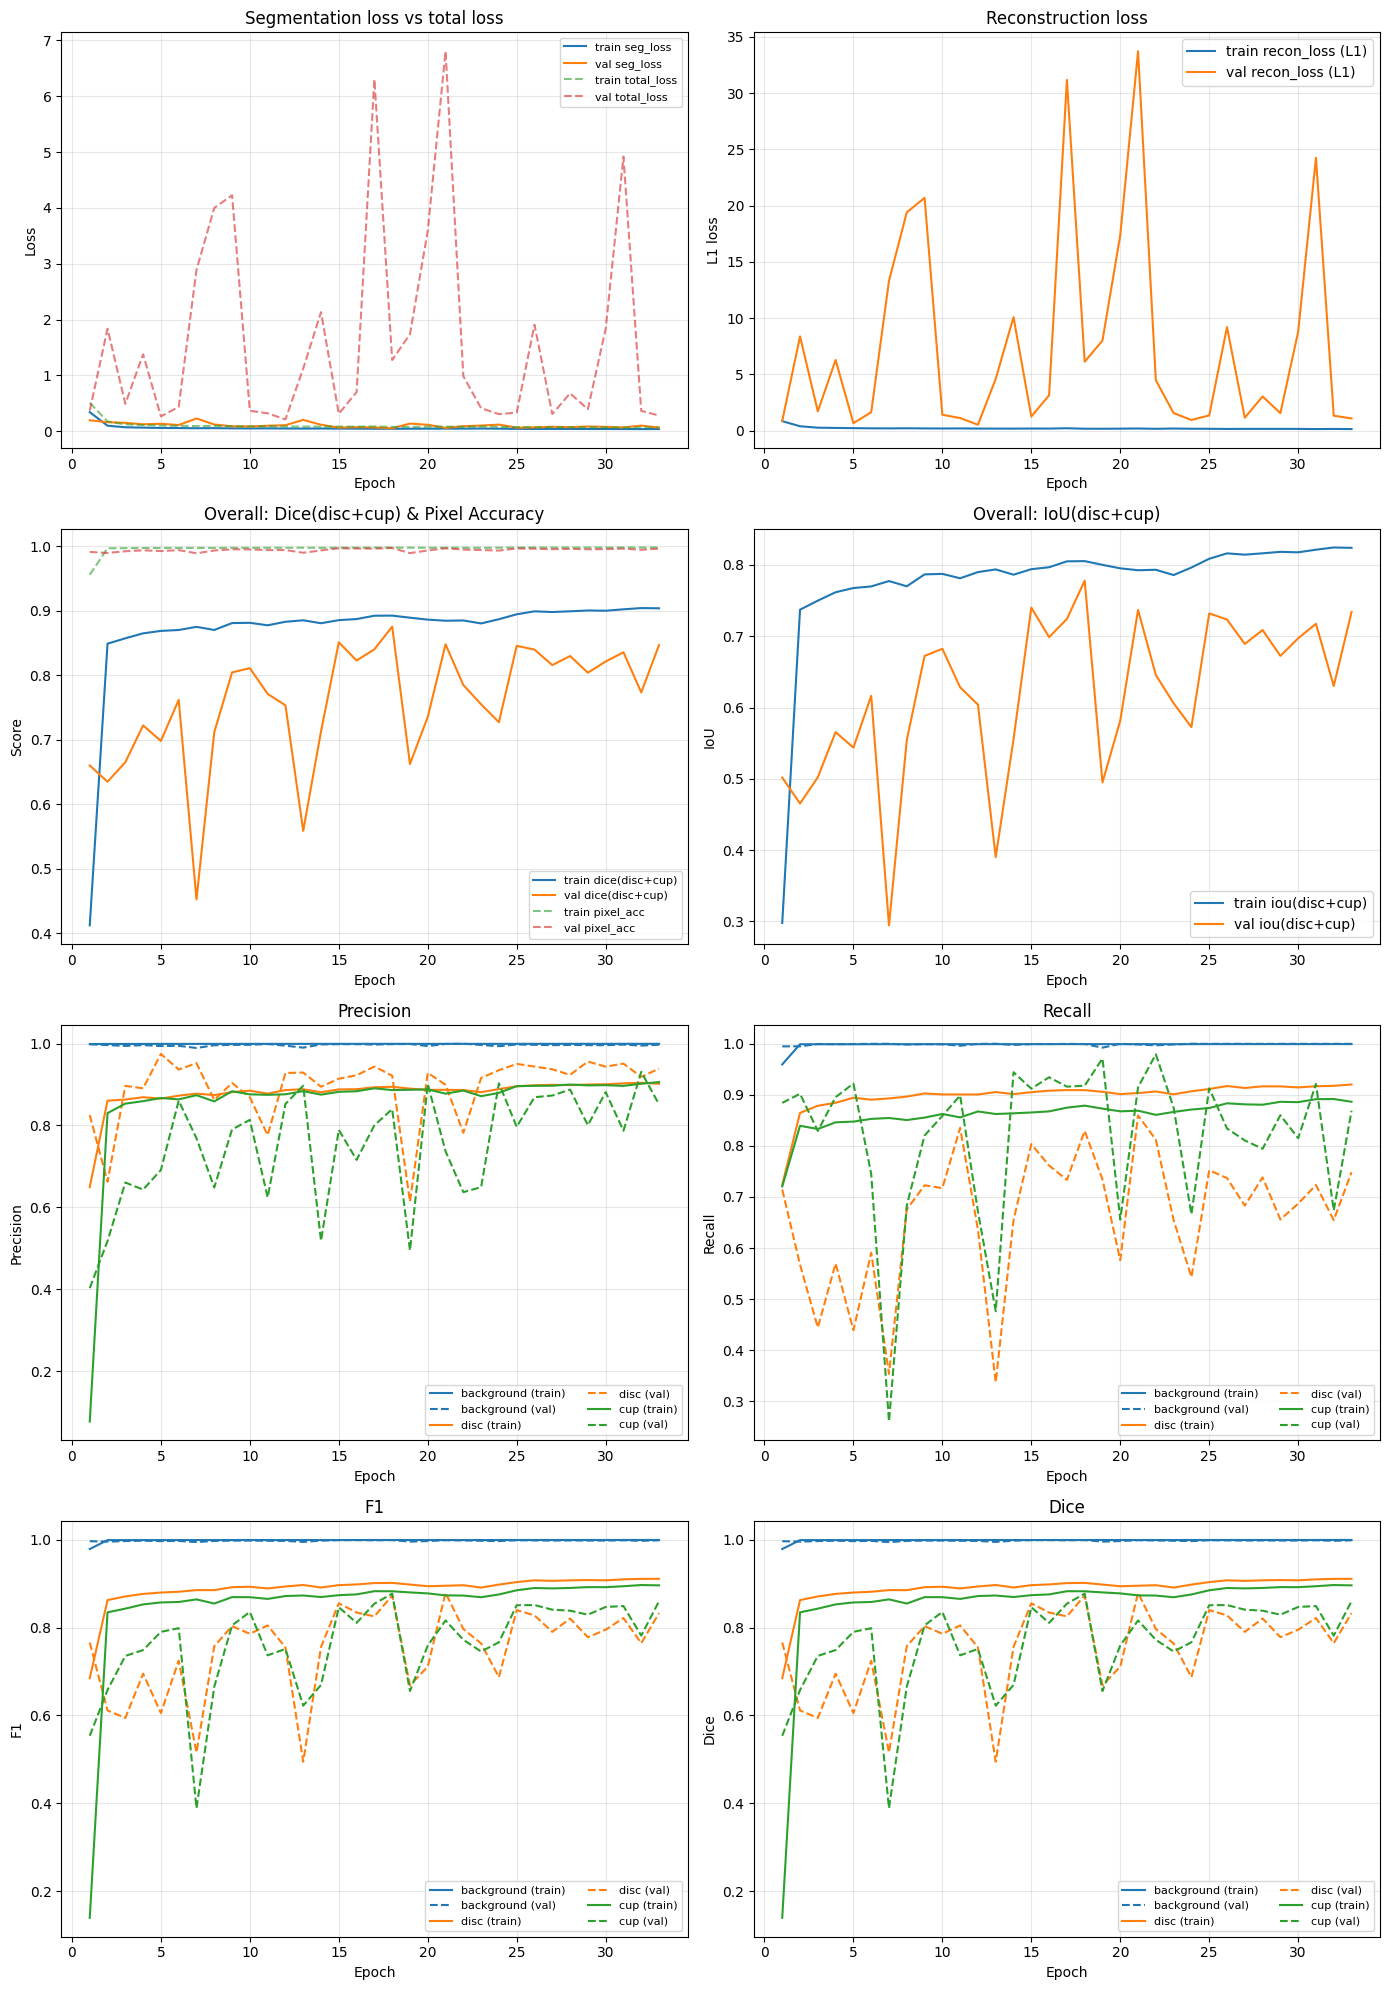

Saved to /content/seg_recon_training_curves.png


In [31]:
import matplotlib.pyplot as plt

epochs_range2 = range(1, len(history2["train_total_loss"]) + 1)
class_names = ["background", "disc", "cup"]
per_class_metrics = ["precision_per_class", "recall_per_class", "f1_per_class", "dice_per_class"]

def get_curve2(split, key, class_idx=None):
    vals = history2[split]
    if class_idx is not None:
        return [m[key][class_idx] for m in vals]
    return [m[key] for m in vals]

fig, axes = plt.subplots(4, 2, figsize=(14, 20))

# 1. Total / seg / recon loss, all on one plot so you can see how much
#    the recon term is contributing to the total vs the seg loss alone
ax = axes[0, 0]
ax.plot(epochs_range2, history2["train_seg_loss"], label="train seg_loss")
ax.plot(epochs_range2, history2["val_seg_loss"], label="val seg_loss")
ax.plot(epochs_range2, history2["train_total_loss"], "--", alpha=0.6, label="train total_loss")
ax.plot(epochs_range2, history2["val_total_loss"], "--", alpha=0.6, label="val total_loss")
ax.set_title("Segmentation loss vs total loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 2. Reconstruction loss on its own axis (different scale from seg loss)
ax = axes[0, 1]
ax.plot(epochs_range2, history2["train_recon_loss"], label="train recon_loss (L1)")
ax.plot(epochs_range2, history2["val_recon_loss"], label="val recon_loss (L1)")
ax.set_title("Reconstruction loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("L1 loss"); ax.legend(); ax.grid(alpha=0.3)

# 3. Overall dice(disc+cup) + pixel accuracy
ax = axes[1, 0]
ax.plot(epochs_range2, get_curve2("train_metrics", "dice_disc_cup_mean"), label="train dice(disc+cup)")
ax.plot(epochs_range2, get_curve2("val_metrics", "dice_disc_cup_mean"), label="val dice(disc+cup)")
ax.plot(epochs_range2, get_curve2("train_metrics", "pixel_accuracy"), "--", alpha=0.6, label="train pixel_acc")
ax.plot(epochs_range2, get_curve2("val_metrics", "pixel_accuracy"), "--", alpha=0.6, label="val pixel_acc")
ax.set_title("Overall: Dice(disc+cup) & Pixel Accuracy")
ax.set_xlabel("Epoch"); ax.set_ylabel("Score"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 4. IoU (disc+cup) as a second overall summary metric
ax = axes[1, 1]
ax.plot(epochs_range2, get_curve2("train_metrics", "iou_disc_cup_mean"), label="train iou(disc+cup)")
ax.plot(epochs_range2, get_curve2("val_metrics", "iou_disc_cup_mean"), label="val iou(disc+cup)")
ax.set_title("Overall: IoU(disc+cup)")
ax.set_xlabel("Epoch"); ax.set_ylabel("IoU"); ax.legend(); ax.grid(alpha=0.3)

# 5-8. Per-class precision/recall/f1/dice, train vs val
positions = [(2, 0), (2, 1), (3, 0), (3, 1)]
metric_titles = {
    "precision_per_class": "Precision", "recall_per_class": "Recall",
    "f1_per_class": "F1", "dice_per_class": "Dice",
}
for (row, col), metric_key in zip(positions, per_class_metrics):
    ax = axes[row, col]
    for class_idx, cname in enumerate(class_names):
        train_curve = get_curve2("train_metrics", metric_key, class_idx)
        val_curve = get_curve2("val_metrics", metric_key, class_idx)
        line, = ax.plot(epochs_range2, train_curve, label=f"{cname} (train)")
        ax.plot(epochs_range2, val_curve, "--", color=line.get_color(), label=f"{cname} (val)")
    ax.set_title(metric_titles[metric_key])
    ax.set_xlabel("Epoch"); ax.set_ylabel(metric_titles[metric_key])
    ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/seg_recon_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to /content/seg_recon_training_curves.png")

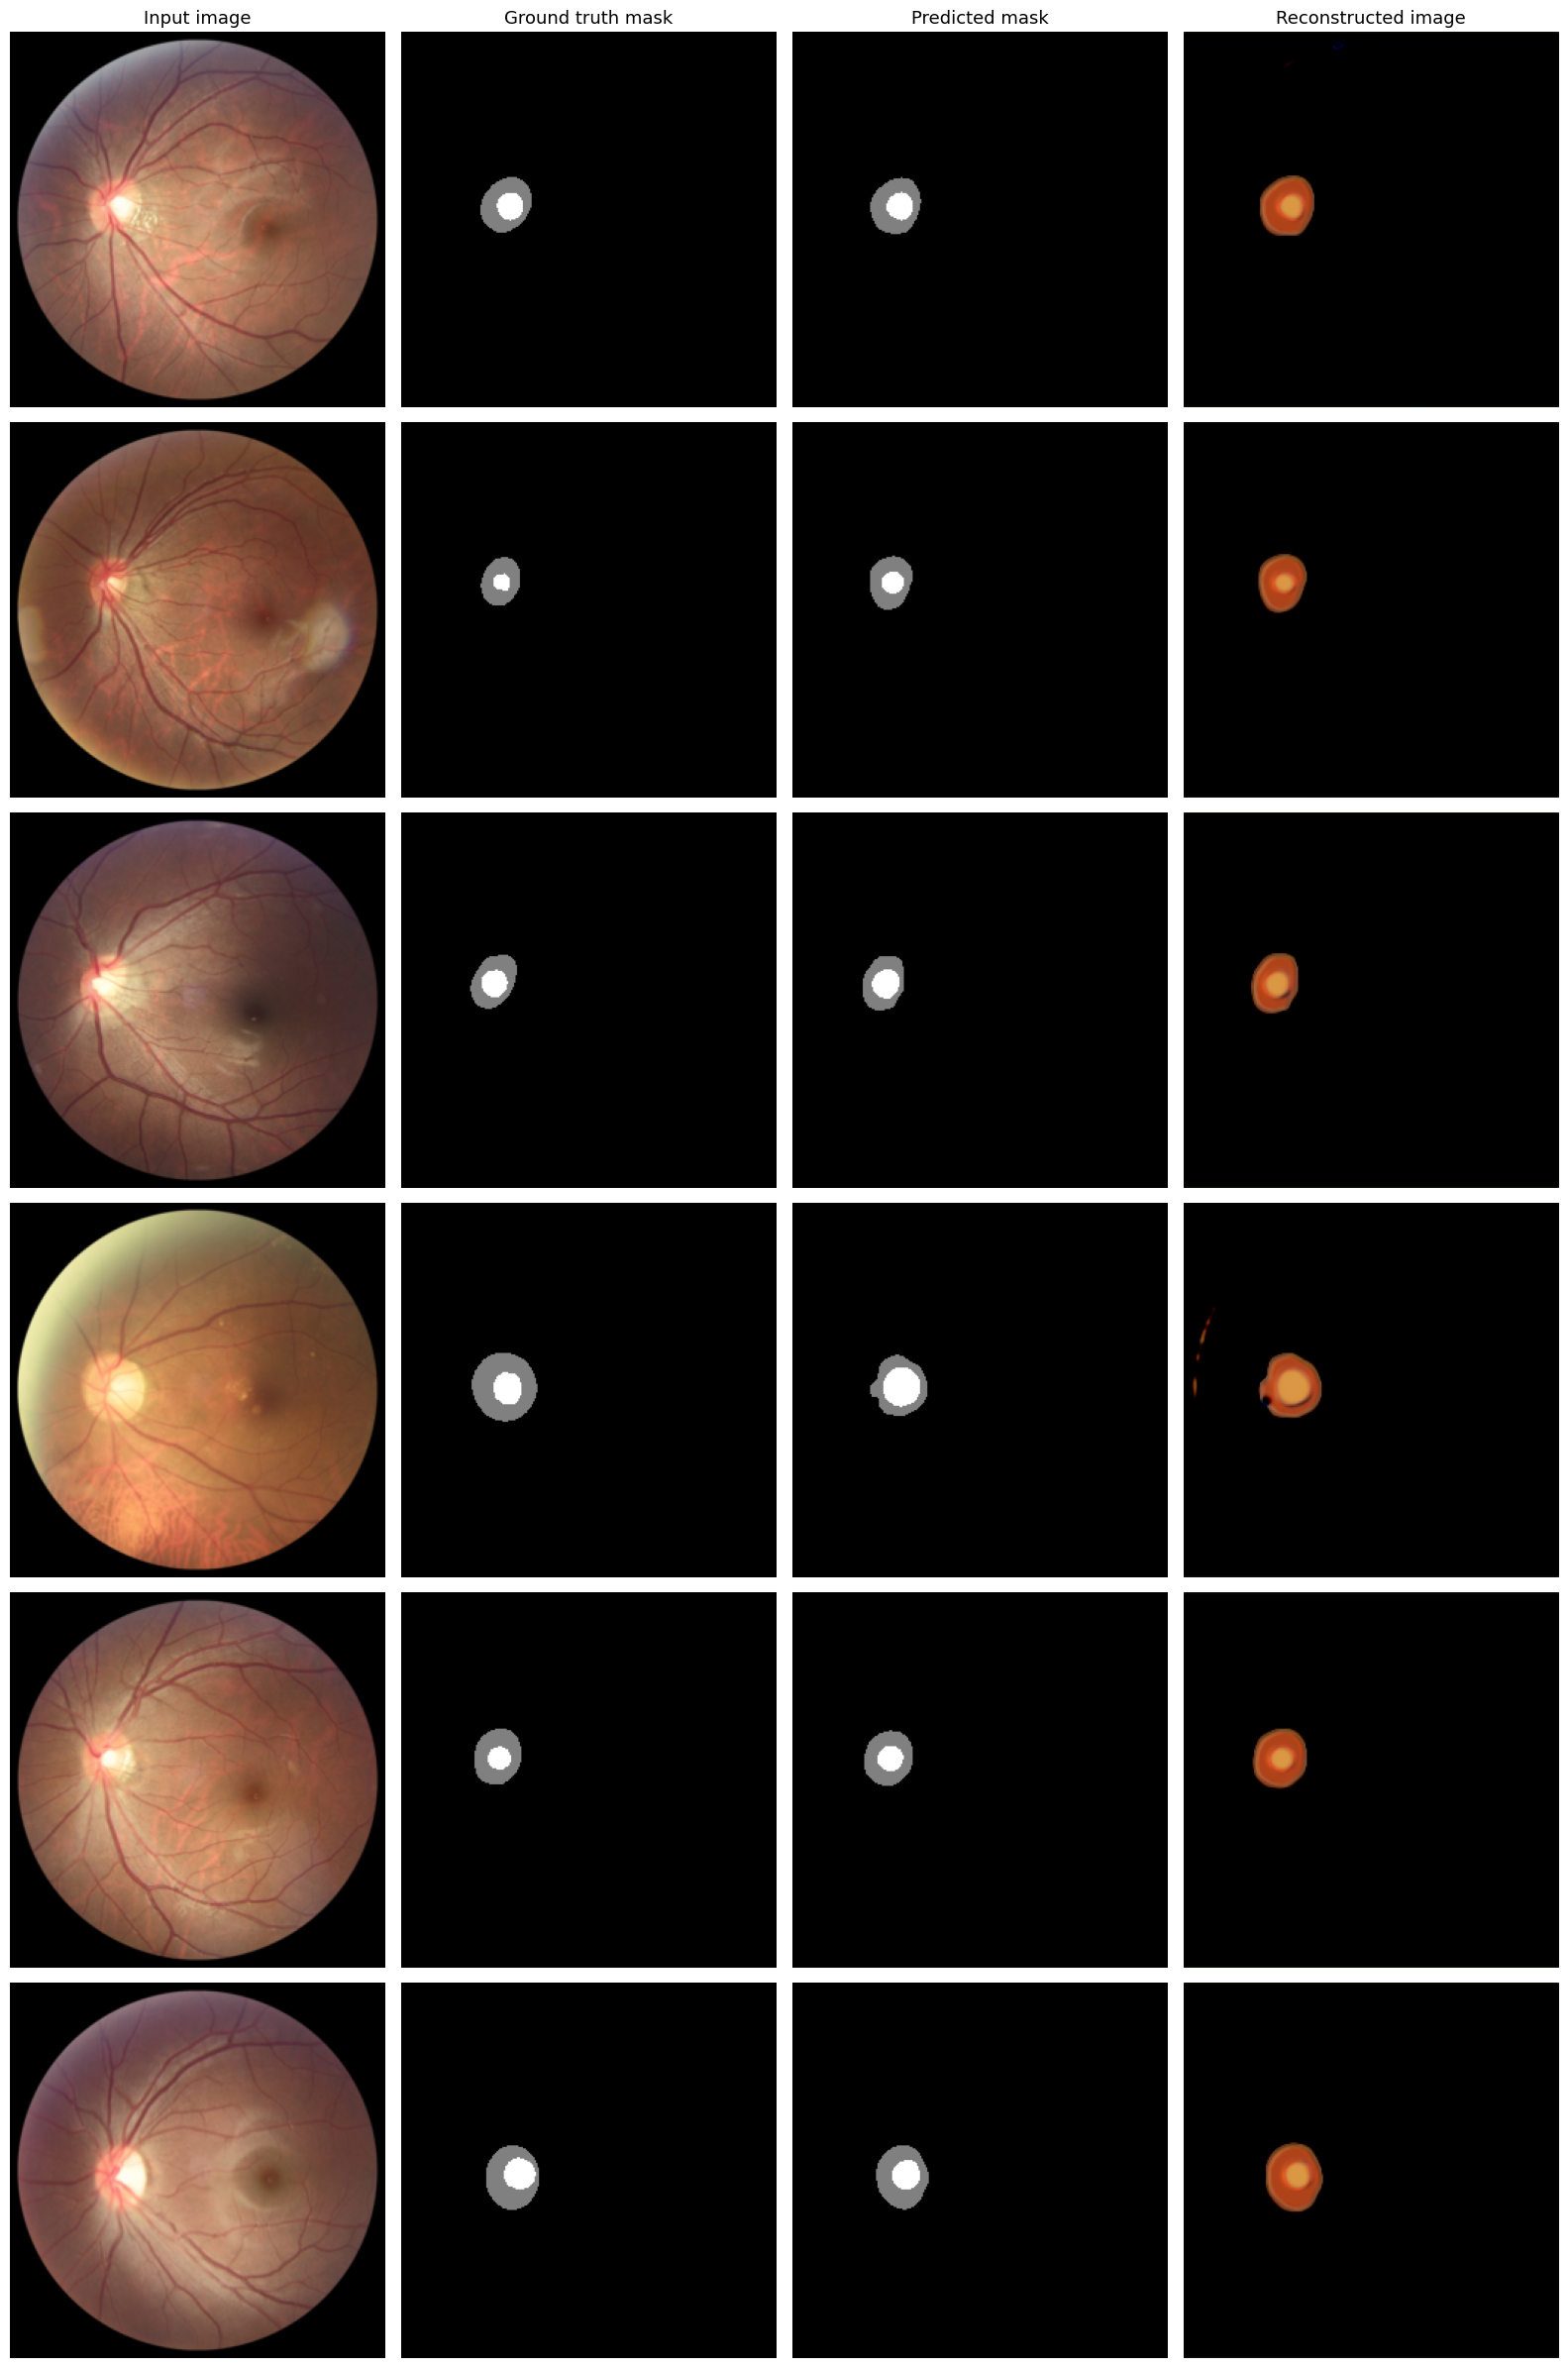

Saved to /content/seg_recon_qualitative.png


In [32]:
N_SAMPLES = 6

images, masks = next(iter(test_loader))
images_dev = images.to(device)

seg_recon_test_model.eval()
with torch.no_grad():
    seg_logits, recon_images = seg_recon_test_model(images_dev)
    preds = torch.argmax(seg_logits, dim=1).cpu()
    recon_images = recon_images.cpu()

def denormalize(img_tensor):
    """CHW normalized tensor -> HWC [0,1] float image, for display only."""
    mean = np.array(IMAGENET_MEAN); std = np.array(IMAGENET_STD)
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = img * std + mean
    return np.clip(img, 0, 1)

n = min(N_SAMPLES, images.size(0))
fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
if n == 1:
    axes = axes[None, :]

col_titles = ["Input image", "Ground truth mask", "Predicted mask", "Reconstructed image"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13)

for i in range(n):
    axes[i, 0].imshow(denormalize(images[i]))
    axes[i, 1].imshow(masks[i].numpy(), cmap="gray")     # raw {0,1,2} values, no color mapping
    axes[i, 2].imshow(preds[i].numpy(), cmap="gray")     # same scale, directly comparable to col 1
    axes[i, 3].imshow(denormalize(recon_images[i]))      # what the recon decoder generated from the mask alone

    for ax in axes[i]:
        ax.axis("off")

plt.tight_layout()
plt.savefig("/content/seg_recon_qualitative.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to /content/seg_recon_qualitative.png")